# AI-3: Prediksi/Forecasting ETI (Expected Trend Index)

Notebook ini untuk eksperimen dan training pipeline **AI-3**:
- Menghitung ETI Score (Expected Trend Index) per responden
- Prediksi tren kepuasan: Naik (5-10%), Stabil, atau Turun
- Prediksi preferensi menggunakan Random Forest
- Evaluasi performa model (RMSE, MAE, R²)

## Komponen ETI Score:
- Skor sentimen individu (0-1)
- Skor kepuasan rata-rata (0-1)
- Konsistensi preferensi (0-1)
- Penyimpangan nilai ekstrem (0-1)

## Logika Keputusan:
- **ETI > 0.7** → Prediksi naik 5-10%
- **ETI 0.4 - 0.7** → Stabil
- **ETI < 0.4** → Prediksi turun


In [1]:
# Install dependencies jika belum ada
%pip install pandas numpy scikit-learn matplotlib seaborn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import sys
import os
from pathlib import Path
import json

# Add parent directory to path untuk import service
notebook_dir = Path().resolve()
# Dari: service_python/ai_training/forecasting/
# Ke: service_python/
project_root = notebook_dir.parent.parent
sys.path.insert(0, str(project_root))

# Alternatif: jika menjalankan dari root project
if not (project_root / "app").exists():
    cwd = Path.cwd()
    if (cwd / "app").exists():
        project_root = cwd
        sys.path.insert(0, str(project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
try:
    import seaborn as sns
except ImportError:
    print("⚠️  seaborn tidak terinstall, beberapa visualisasi mungkin tidak tersedia")
    sns = None
from typing import List, Dict, Any, Optional

# Import service AI-3
try:
    from app.src.services.forecasting_service import (
        forecast_eti_trend,
        calculate_eti_score,
        calculate_preference_consistency,
        calculate_extreme_deviation,
        predict_trend_with_linear_regression,
    )
    print("✅ Import berhasil menggunakan: app.src.services...")
except ImportError as e1:
    try:
        from service_python.app.src.services.forecasting_service import (
            forecast_eti_trend,
            calculate_eti_score,
            calculate_preference_consistency,
            calculate_extreme_deviation,
            predict_trend_with_linear_regression,
        )
        print("✅ Import berhasil menggunakan: service_python.app.src.services...")
    except ImportError as e2:
        import importlib.util
        service_path = project_root / "app" / "src" / "services" / "forecasting_service.py"
        if service_path.exists():
            spec = importlib.util.spec_from_file_location("forecasting_service", service_path)
            module = importlib.util.module_from_spec(spec)
            spec.loader.exec_module(module)
            forecast_eti_trend = module.forecast_eti_trend
            calculate_eti_score = module.calculate_eti_score
            calculate_preference_consistency = module.calculate_preference_consistency
            calculate_extreme_deviation = module.calculate_extreme_deviation
            predict_trend_with_linear_regression = module.predict_trend_with_linear_regression
            print("✅ Import berhasil menggunakan: importlib (direct file)")
        else:
            raise ImportError(
                f"Tidak bisa import service. Pastikan path benar.\n"
                f"  Project root: {project_root}\n"
                f"  Service path: {service_path}\n"
                f"  Error 1: {e1}\n"
                f"  Error 2: {e2}"
            )

print("✅ Imports berhasil!")
print(f"Working directory: {notebook_dir}")
print(f"Project root: {project_root}")


✅ Import berhasil menggunakan: app.src.services...
✅ Imports berhasil!
Working directory: C:\Users\User\OneDrive\Documents\3312411050\SEMESTER 3\PBL-2AI\SurvaAnalytics\service_python\ai_training\forecasting
Project root: C:\Users\User\OneDrive\Documents\3312411050\SEMESTER 3\PBL-2AI\SurvaAnalytics\service_python


## 1. Load Dataset Dummy

Generate dataset dummy dengan data historis untuk testing forecasting.


In [3]:
def load_dummy_forecasting_data():
    """
    Generate dataset dummy untuk testing AI-3.
    """
    # Data saat ini (dari AI-1)
    sentiment_scores = [0.92, 0.65, 0.3, 0.5, 0.95, 0.45]
    satisfaction_scores = [0.933, 0.6, 0.4, 0.667, 1.0, 0.667]
    
    # Riwayat kepuasan (3 periode sebelumnya)
    satisfaction_history = [
        [0.8, 0.85, 0.9, 0.933],  # Responden 1: tren naik
        [0.7, 0.65, 0.6, 0.6],     # Responden 2: tren turun
        [0.5, 0.45, 0.4, 0.4],     # Responden 3: tren turun
        [0.6, 0.65, 0.667, 0.667], # Responden 4: tren naik lalu stabil
        [0.9, 0.95, 1.0, 1.0],     # Responden 5: tren naik lalu stabil tinggi
        [0.7, 0.65, 0.667, 0.667], # Responden 6: tren turun lalu stabil
    ]
    
    # Riwayat preferensi (3 periode sebelumnya)
    historical_preferences = [
        [
            {"prefer_product_x": 1, "prefer_product_y": 0, "prefer_online": 1},
            {"prefer_product_x": 1, "prefer_product_y": 0, "prefer_online": 1},
            {"prefer_product_x": 1, "prefer_product_y": 0, "prefer_online": 1},
            {"prefer_product_x": 1, "prefer_product_y": 0, "prefer_online": 1},
        ],  # Responden 1: sangat konsisten
        [
            {"prefer_product_x": 0, "prefer_product_y": 1, "prefer_online": 0},
            {"prefer_product_x": 0.5, "prefer_product_y": 0.5, "prefer_online": 0.5},
            {"prefer_product_x": 1, "prefer_product_y": 0, "prefer_online": 1},
            {"prefer_product_x": 1, "prefer_product_y": 0, "prefer_online": 1},
        ],  # Responden 2: tidak konsisten
        [
            {"prefer_product_x": 0, "prefer_product_y": 1, "prefer_online": 0},
            {"prefer_product_x": 0, "prefer_product_y": 1, "prefer_online": 0},
            {"prefer_product_x": 0, "prefer_product_y": 1, "prefer_online": 0},
            {"prefer_product_x": 0, "prefer_product_y": 1, "prefer_online": 0},
        ],  # Responden 3: konsisten
        [
            {"prefer_product_x": 1, "prefer_product_y": 0, "prefer_online": 1},
            {"prefer_product_x": 1, "prefer_product_y": 0, "prefer_online": 1},
            {"prefer_product_x": 0.8, "prefer_product_y": 0.2, "prefer_online": 0.8},
            {"prefer_product_x": 0.8, "prefer_product_y": 0.2, "prefer_online": 0.8},
        ],  # Responden 4: cukup konsisten
        [
            {"prefer_product_x": 1, "prefer_product_y": 0, "prefer_online": 1},
            {"prefer_product_x": 1, "prefer_product_y": 0, "prefer_online": 1},
            {"prefer_product_x": 1, "prefer_product_y": 0, "prefer_online": 1},
            {"prefer_product_x": 1, "prefer_product_y": 0, "prefer_online": 1},
        ],  # Responden 5: sangat konsisten
        [
            {"prefer_product_x": 0.5, "prefer_product_y": 0.5, "prefer_online": 0.5},
            {"prefer_product_x": 0.6, "prefer_product_y": 0.4, "prefer_online": 0.6},
            {"prefer_product_x": 0.7, "prefer_product_y": 0.3, "prefer_online": 0.7},
            {"prefer_product_x": 0.7, "prefer_product_y": 0.3, "prefer_online": 0.7},
        ],  # Responden 6: cukup konsisten
    ]
    
    # Preferensi saat ini
    current_preferences = [
        {"prefer_product_x": 1, "prefer_product_y": 0, "prefer_online": 1},
        {"prefer_product_x": 1, "prefer_product_y": 0, "prefer_online": 1},
        {"prefer_product_x": 0, "prefer_product_y": 1, "prefer_online": 0},
        {"prefer_product_x": 0.8, "prefer_product_y": 0.2, "prefer_online": 0.8},
        {"prefer_product_x": 1, "prefer_product_y": 0, "prefer_online": 1},
        {"prefer_product_x": 0.7, "prefer_product_y": 0.3, "prefer_online": 0.7},
    ]
    
    return {
        "sentiment_scores": sentiment_scores,
        "satisfaction_scores": satisfaction_scores,
        "satisfaction_history": satisfaction_history,
        "historical_preferences": historical_preferences,
        "current_preferences": current_preferences,
    }


# Load dataset
data = load_dummy_forecasting_data()
print(f"✅ Dataset loaded: {len(data['sentiment_scores'])} responden")
print(f"\nContoh data:")
print(f"  Sentiment scores: {data['sentiment_scores']}")
print(f"  Satisfaction scores: {data['satisfaction_scores']}")
print(f"  Satisfaction history (responden 1): {data['satisfaction_history'][0]}")


✅ Dataset loaded: 6 responden

Contoh data:
  Sentiment scores: [0.92, 0.65, 0.3, 0.5, 0.95, 0.45]
  Satisfaction scores: [0.933, 0.6, 0.4, 0.667, 1.0, 0.667]
  Satisfaction history (responden 1): [0.8, 0.85, 0.9, 0.933]


In [4]:
# Jalankan AI-3: Forecasting ETI Trend
result = forecast_eti_trend(
    sentiment_scores=data["sentiment_scores"],
    satisfaction_scores=data["satisfaction_scores"],
    satisfaction_history=data["satisfaction_history"],
    historical_preferences=data["historical_preferences"],
    current_preferences=data["current_preferences"],
    weights=None,  # Gunakan default weights
)

print("=" * 60)
print("AI-3: HASIL FORECASTING ETI TREND")
print("=" * 60)

print(f"\n📊 ETI Scores per Responden:")
for i, eti in enumerate(result["eti_scores"]):
    print(f"  Responden {i+1}: {eti:.3f}")

print(f"\n📈 Prediksi Tren:")
for i, (trend, pct) in enumerate(zip(result["trend_predictions"], result["trend_percentages"])):
    pct_str = f"{pct:+.1f}%" if pct != 0 else "0%"
    print(f"  Responden {i+1}: {trend.upper()} ({pct_str})")

print(f"\n🔍 Konsistensi Preferensi:")
for i, consistency in enumerate(result["preference_consistency"]):
    print(f"  Responden {i+1}: {consistency:.3f}")

print(f"\n⚠️  Penyimpangan Ekstrem:")
for i, deviation in enumerate(result["extreme_deviation"]):
    print(f"  Responden {i+1}: {deviation:.3f}")

if result.get("predicted_satisfaction"):
    print(f"\n🎯 Prediksi Skor Kepuasan Berikutnya:")
    for i, pred in enumerate(result["predicted_satisfaction"]):
        print(f"  Responden {i+1}: {pred:.3f}")

if result.get("metrics"):
    print(f"\n📊 Metrics Evaluasi:")
    for metric, value in result["metrics"].items():
        print(f"  {metric.upper()}: {value:.3f}")


AI-3: HASIL FORECASTING ETI TREND

📊 ETI Scores per Responden:
  Responden 1: 0.956
  Responden 2: 0.584
  Responden 3: 0.610
  Responden 4: 0.704
  Responden 5: 0.985
  Responden 6: 0.697

📈 Prediksi Tren:
  Responden 1: NAIK (+9.5%)
  Responden 2: STABIL (0%)
  Responden 3: STABIL (0%)
  Responden 4: NAIK (+5.1%)
  Responden 5: NAIK (+9.5%)
  Responden 6: STABIL (0%)

🔍 Konsistensi Preferensi:
  Responden 1: 1.000
  Responden 2: 0.043
  Responden 3: 1.000
  Responden 4: 0.769
  Responden 5: 1.000
  Responden 6: 0.809

⚠️  Penyimpangan Ekstrem:
  Responden 1: 0.000
  Responden 2: 0.000
  Responden 3: 0.000
  Responden 4: 0.000
  Responden 5: 0.000
  Responden 6: 0.000

🎯 Prediksi Skor Kepuasan Berikutnya:
  Responden 1: 0.983
  Responden 2: 0.550
  Responden 3: 0.350
  Responden 4: 0.701
  Responden 5: 1.000
  Responden 6: 0.651

📊 Metrics Evaluasi:
  RMSE: 0.012
  MAE: 0.012
  R2: 0.996


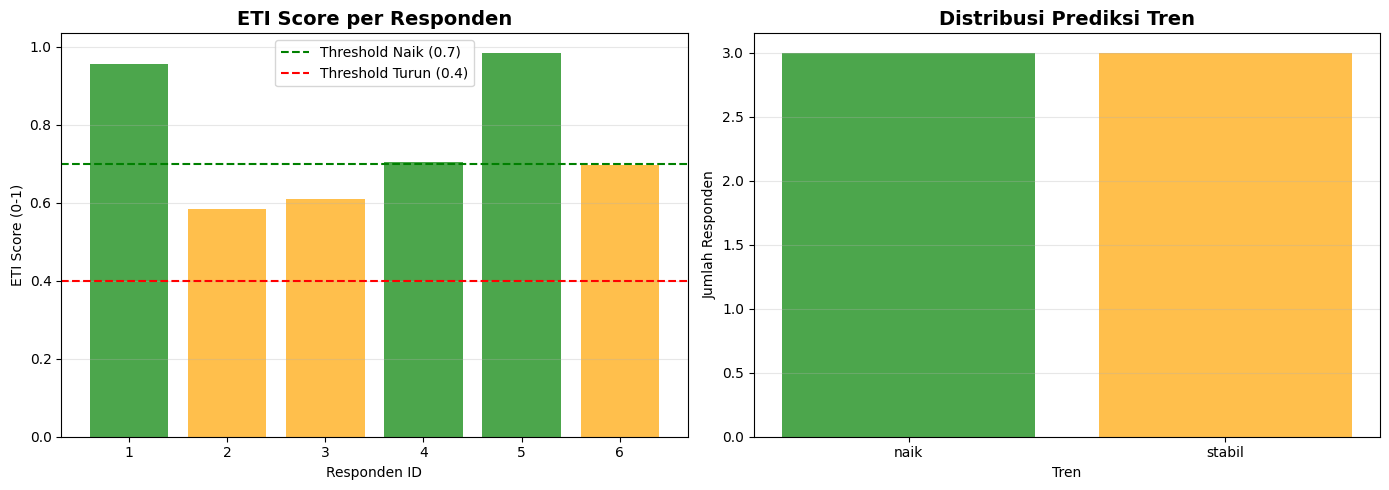

In [5]:
# Visualisasi: ETI Score vs Prediksi Tren
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: ETI Score per Responden
respondent_ids = range(1, len(result["eti_scores"]) + 1)
eti_scores = result["eti_scores"]

colors = []
for eti in eti_scores:
    if eti > 0.7:
        colors.append('green')
    elif eti < 0.4:
        colors.append('red')
    else:
        colors.append('orange')

axes[0].bar(respondent_ids, eti_scores, color=colors, alpha=0.7)
axes[0].axhline(y=0.7, color='green', linestyle='--', label='Threshold Naik (0.7)')
axes[0].axhline(y=0.4, color='red', linestyle='--', label='Threshold Turun (0.4)')
axes[0].set_title('ETI Score per Responden', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Responden ID')
axes[0].set_ylabel('ETI Score (0-1)')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: Distribusi Prediksi Tren
trend_counts = {}
for trend in result["trend_predictions"]:
    trend_counts[trend] = trend_counts.get(trend, 0) + 1

trend_labels = list(trend_counts.keys())
trend_values = list(trend_counts.values())
trend_colors = {'naik': 'green', 'stabil': 'orange', 'turun': 'red'}
colors_plot = [trend_colors.get(t, 'gray') for t in trend_labels]

axes[1].bar(trend_labels, trend_values, color=colors_plot, alpha=0.7)
axes[1].set_title('Distribusi Prediksi Tren', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Tren')
axes[1].set_ylabel('Jumlah Responden')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


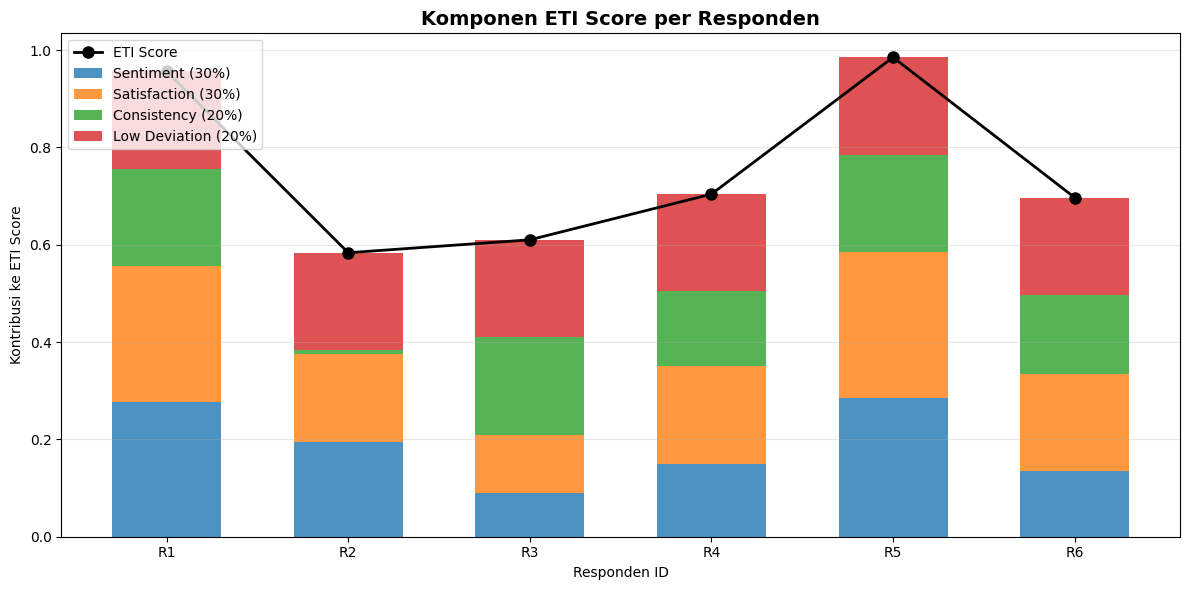

In [6]:
# Visualisasi: Komponen ETI Score
if len(result["eti_scores"]) > 0:
    n_respondents = len(result["eti_scores"])
    
    # Siapkan data untuk stacked bar chart
    sentiment_contrib = [s * 0.3 for s in data["sentiment_scores"]]
    satisfaction_contrib = [s * 0.3 for s in data["satisfaction_scores"]]
    consistency_contrib = [c * 0.2 for c in result["preference_consistency"]]
    deviation_contrib = [(1 - d) * 0.2 for d in result["extreme_deviation"]]
    
    x = np.arange(n_respondents)
    width = 0.6
    
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.bar(x, sentiment_contrib, width, label='Sentiment (30%)', alpha=0.8)
    ax.bar(x, satisfaction_contrib, width, bottom=sentiment_contrib, 
           label='Satisfaction (30%)', alpha=0.8)
    ax.bar(x, consistency_contrib, width, 
           bottom=[s + sat for s, sat in zip(sentiment_contrib, satisfaction_contrib)],
           label='Consistency (20%)', alpha=0.8)
    ax.bar(x, deviation_contrib, width,
           bottom=[s + sat + c for s, sat, c in zip(sentiment_contrib, satisfaction_contrib, consistency_contrib)],
           label='Low Deviation (20%)', alpha=0.8)
    
    # Tambahkan garis ETI score
    ax.plot(x, result["eti_scores"], 'ko-', label='ETI Score', linewidth=2, markersize=8)
    
    ax.set_xlabel('Responden ID')
    ax.set_ylabel('Kontribusi ke ETI Score')
    ax.set_title('Komponen ETI Score per Responden', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([f'R{i+1}' for i in range(n_respondents)])
    ax.legend(loc='upper left')
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()


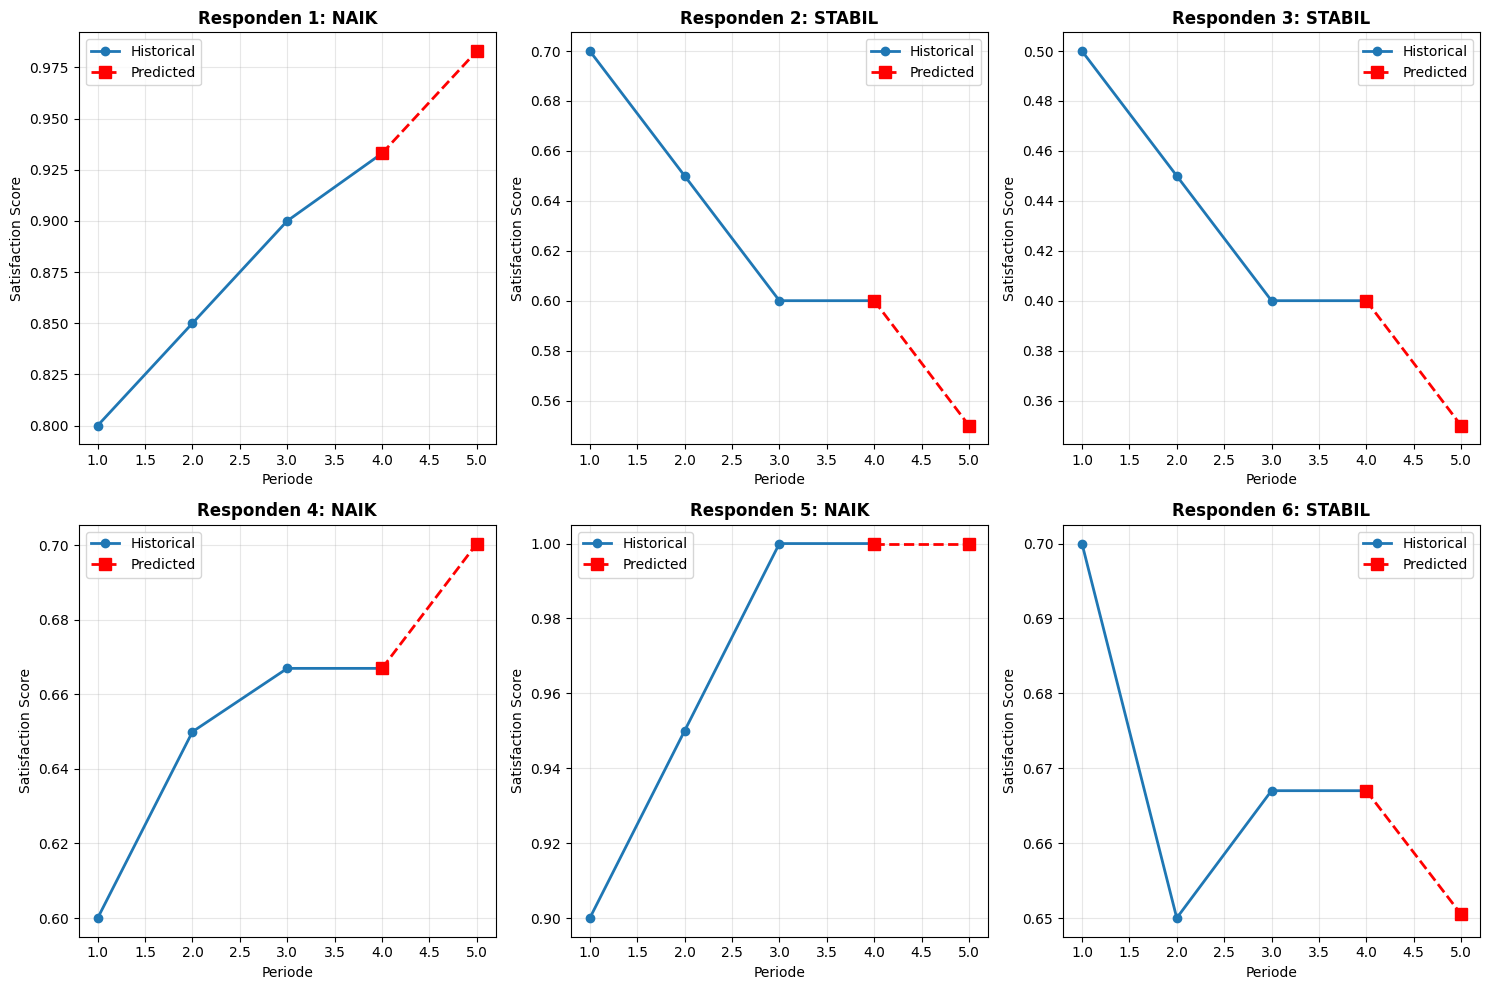

In [7]:
# Visualisasi: Riwayat Kepuasan & Prediksi (jika ada)
if result.get("predicted_satisfaction") and data["satisfaction_history"]:
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    for i in range(min(6, len(data["satisfaction_history"]))):
        history = data["satisfaction_history"][i]
        predicted = result["predicted_satisfaction"][i]
        trend = result["trend_predictions"][i]
        
        # Plot history
        periods = list(range(1, len(history) + 1))
        axes[i].plot(periods, history, 'o-', label='Historical', linewidth=2, markersize=6)
        
        # Plot prediction
        next_period = len(history) + 1
        axes[i].plot([periods[-1], next_period], [history[-1], predicted], 
                    'r--', label='Predicted', linewidth=2, marker='s', markersize=8)
        
        axes[i].set_title(f'Responden {i+1}: {trend.upper()}', fontweight='bold')
        axes[i].set_xlabel('Periode')
        axes[i].set_ylabel('Satisfaction Score')
        axes[i].legend()
        axes[i].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()


## 3. Export Hasil AI-3

Export hasil forecasting untuk analisis lebih lanjut.


In [8]:
# Buat DataFrame lengkap dengan hasil AI-3
df_results = pd.DataFrame({
    'respondent_id': range(1, len(result["eti_scores"]) + 1),
    'eti_score': result["eti_scores"],
    'trend_prediction': result["trend_predictions"],
    'trend_percentage': result["trend_percentages"],
    'preference_consistency': result["preference_consistency"],
    'extreme_deviation': result["extreme_deviation"],
})

if result.get("predicted_satisfaction"):
    df_results['predicted_satisfaction'] = result["predicted_satisfaction"]

print("=" * 60)
print("RINGKASAN HASIL AI-3")
print("=" * 60)
print("\n📊 DataFrame Hasil:")
print(df_results)

# Export ke CSV
output_file = 'eti_forecasting_results.csv'
df_results.to_csv(output_file, index=False)
print(f"\n✅ Hasil diexport ke: {output_file}")

# Export detail ke JSON
output_json = {
    'eti_scores': result['eti_scores'],
    'trend_predictions': result['trend_predictions'],
    'trend_percentages': result['trend_percentages'],
    'predicted_satisfaction': result.get('predicted_satisfaction'),
    'regression_trends': result.get('regression_trends'),
    'preference_predictions': result.get('preference_predictions', {}),
    'feature_importance': result.get('feature_importance', {}),
    'metrics': result.get('metrics', {}),
}

json_file = 'eti_forecasting_results.json'
with open(json_file, 'w', encoding='utf-8') as f:
    json.dump(output_json, f, indent=2, ensure_ascii=False)
print(f"✅ Hasil JSON diexport ke: {json_file}")


RINGKASAN HASIL AI-3

📊 DataFrame Hasil:
   respondent_id  eti_score trend_prediction  trend_percentage  \
0              1   0.955900             naik          9.546506   
1              2   0.583515           stabil          0.000000   
2              3   0.610000           stabil          0.000000   
3              4   0.703912             naik          5.091363   
4              5   0.985000             naik          9.482620   
5              6   0.696803           stabil          0.000000   

   preference_consistency  extreme_deviation  predicted_satisfaction  
0                1.000000                0.0                  0.9830  
1                0.042573                0.0                  0.5500  
2                1.000000                0.0                  0.3500  
3                0.769060                0.0                  0.7005  
4                1.000000                0.0                  1.0000  
5                0.808515                0.0                  0.6505  